In [5]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


In [6]:
# ================================
# Part 1: Data Import & Inspection
# ================================

# 1. Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder


sns.set(style="whitegrid")
%matplotlib inline

# 2. Load the dataset
df = pd.read_csv("train.csv")

# 3. First 10 and last 5 rows
print("First 10 rows:")
display(df.head(10))

print("\nLast 5 rows:")
display(df.tail(5))

# 4. Shape of the dataset
print(f"\nDataset shape: {df.shape[0]} rows and {df.shape[1]} columns")

# 5. Data types of all columns
print("\nData types:")
print(df.dtypes)

# 6. Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumber of numerical columns: {len(numerical_cols)}")
print("Numerical columns:", numerical_cols)

print(f"\nNumber of categorical columns: {len(categorical_cols)}")
print("Categorical columns:", categorical_cols)

# 7. Basic statistics
print("\nSummary statistics (numerical columns):")
display(df.describe())

print("\nSummary statistics (categorical columns):")
display(df.describe(include=['object']))

First 10 rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000



Last 5 rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500



Dataset shape: 1460 rows and 81 columns

Data types:
Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object

Number of numerical columns: 38
Numerical columns: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Number of categorical columns: 43
Categorical columns: ['MSZoning', 'Str

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000



Summary statistics (categorical columns):


,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,...,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,...,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,...,870,605,1311,1326,1340,3,157,49,1267,1198


## Feature Descriptions

This dataset describes residential home sales in Ames, Iowa, and is used to
predict `SalePrice`. Key features include:

- **Id** – Unique identifier for each house (not predictive, used for indexing)
- **MSSubClass** – Type of dwelling (e.g., 1-story, 2-story, split-level)
- **MSZoning** – General zoning classification (e.g., Residential Low/Medium density)
- **LotFrontage** – Linear feet of street connected to the property
- **LotArea** – Lot size in square feet
- **Street / Alley** – Type of road/alley access
- **LotShape** – General shape of the property (regular/irregular)
- **Neighborhood** – Physical location within Ames city limits
- **OverallQual / OverallCond** – Overall material/finish quality and condition (1–10 scale)
- **YearBuilt / YearRemodAdd** – Original construction year and remodel year
- **TotalBsmtSF, 1stFlrSF, 2ndFlrSF, GrLivArea** – Square footage of basement, 1st floor, 2nd floor, and above-ground living area
- **FullBath / HalfBath, BedroomAbvGr, KitchenAbvGr** – Room counts
- **GarageCars / GarageArea** – Garage capacity and size
- **YrSold / MoSold** – Year and month the house was sold
- **SaleType / SaleCondition** – Type and condition of sale (e.g., normal, foreclosure)
- **SalePrice** – Target variable: the sale price of the house in USD

The dataset mixes **numerical features** (areas, counts, years, prices) with
**categorical features** (zoning, neighborhood, quality ratings, styles), and
several columns contain `NA` to represent "feature not present" (e.g., `Alley`,
`PoolQC`, `Fence`) rather than missing data in the traditional sense.

In [7]:
# ================================
# Part 2: Data Cleaning
# ================================

# 1. Check for missing values in each column
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)

missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct.round(2)})
display(missing_df)

Columns with missing values:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


,Missing Count,Missing %
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


## Handling Missing Values — Justification

The missing values fall into three distinct groups, and each is handled differently:

**Group 1 — "NA means the feature doesn't exist" (categorical).**
Columns like `PoolQC`, `MiscFeature`, `Alley`, `Fence`, `FireplaceQu`, `GarageType`,
`GarageFinish`, `GarageQual`, `GarageCond`, `BsmtQual`, `BsmtCond`, `BsmtExposure`,
`BsmtFinType1`, `BsmtFinType2` are missing because the house simply doesn't have
that feature (e.g., no pool, no alley access, no basement). Dropping these rows
or columns would throw away useful information. Instead, I fill these with the
string `"None"` to explicitly represent "feature not present."

**Group 2 — Numeric columns tied to the same "doesn't exist" logic.**
`GarageYrBlt` and `MasVnrArea` are missing for the same reason (no garage / no
masonry veneer). These are filled with `0`, since a year or area of 0 sensibly
represents "not applicable" for a numeric field.

**Group 3 — Genuinely missing values needing estimation.**
- `LotFrontage` (259 missing, ~17.7%) is a continuous numeric feature with real
  missingness (frontage was not recorded). I fill it with the **median** grouped
  by `Neighborhood`, since lot frontage varies a lot by location and the median
  is robust to outliers (unlike the mean).
- `MasVnrType` (872 missing) is filled with `"None"` — it aligns with `MasVnrArea`
  being 0 in most of these same rows, confirming no masonry veneer.
- `Electrical` (1 missing) is filled with the **mode** (most frequent category),
  since a single missing value in a categorical column is best imputed with the
  most common value rather than dropped.

I chose **imputation over dropping rows/columns** because several "missing"
columns are actually meaningful categories, and dropping ~1450 rows (for `PoolQC`)
would destroy the dataset. I avoid mean imputation for skewed numeric features
(like `LotFrontage`) and prefer median/group-median instead.

In [8]:
# 2 & 3. Handle missing values

# --- Group 1: Categorical "None" columns ---
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
             'BsmtFinType2', 'MasVnrType']
for col in none_cols:
    df[col] = df[col].fillna("None")

# --- Group 2: Numeric "0" columns ---
zero_cols = ['GarageYrBlt', 'MasVnrArea']
for col in zero_cols:
    df[col] = df[col].fillna(0)

# --- Group 3: Genuine missing values ---
# LotFrontage: median by neighborhood
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

# Electrical: mode
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

# 4. Check for and remove duplicate rows
print(f"Number of duplicate rows: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

# 5. Check for incorrect/impossible values
print("\nSalePrice range:", df['SalePrice'].min(), "-", df['SalePrice'].max())
print("LotArea range:", df['LotArea'].min(), "-", df['LotArea'].max())
print("YearBuilt range:", df['YearBuilt'].min(), "-", df['YearBuilt'].max())
print("GrLivArea range:", df['GrLivArea'].min(), "-", df['GrLivArea'].max())

# Flag any impossible values (negative or zero where it shouldn't be)
impossible = df[(df['SalePrice'] <= 0) | (df['LotArea'] <= 0) |
                 (df['GrLivArea'] <= 0) | (df['YearBuilt'] > 2026)]
print(f"\nRows with impossible values: {len(impossible)}")
# None found in this dataset — all prices/areas are positive and years are valid.

# 6. Verify feature types are correct
# GarageYrBlt and MasVnrArea should be int now that NaNs are filled with 0
df['GarageYrBlt'] = df['GarageYrBlt'].astype(int)
df['MasVnrArea'] = df['MasVnrArea'].astype(int)

# MSSubClass is numeric in the file but is actually a categorical code
# (each number represents a dwelling type, not a magnitude)
df['MSSubClass'] = df['MSSubClass'].astype(str)

print("\nUpdated dtypes:")
print(df.dtypes[['GarageYrBlt', 'MasVnrArea', 'MSSubClass']])

# 7. Confirm cleaned dataset shape and no missing values remain
print(f"\nCleaned dataset shape: {df.shape}")
print(f"Total remaining missing values: {df.isnull().sum().sum()}")

Number of duplicate rows: 0
Shape after removing duplicates: (1460, 81)

SalePrice range: 34900 - 755000
LotArea range: 1300 - 215245
YearBuilt range: 1872 - 2010
GrLivArea range: 334 - 5642

Rows with impossible values: 0

Updated dtypes:
GarageYrBlt     int64
MasVnrArea      int64
MSSubClass     object
dtype: object

Cleaned dataset shape: (1460, 81)
Total remaining missing values: 0


## Cleaning Summary

- Original shape: 1460 rows × 81 columns
- Duplicate rows found and removed: 0
- Missing values handled: 19 columns cleaned via a mix of `"None"`/`0` fill
  (for structurally missing categories) and median/mode imputation (for
  genuinely missing data)
- No impossible values (negative prices, zero areas, invalid years) were found
- `MSSubClass` was recast from numeric to categorical, since its integer codes
  represent dwelling types, not quantities
- Final check: `df.isnull().sum().sum()` returns 0 → dataset is fully clean

In [9]:
# ================================
# Part 3: Exploratory Data Analysis
# ================================

# Exclude Id — it's an identifier, not a real numeric feature
numerical_cols = [c for c in df.select_dtypes(include=['int64','float64']).columns if c != 'Id']

# Key features we'll focus on for detailed stats/plots
key_features = ['SalePrice', 'GrLivArea', 'TotalBsmtSF', 'LotArea',
                 'OverallQual', 'YearBuilt', 'GarageArea', '1stFlrSF']

In [10]:
# 1. Mean, Median, Mode for all numerical columns
summary_stats = pd.DataFrame({
    'Mean': df[numerical_cols].mean(),
    'Median': df[numerical_cols].median(),
    'Mode': df[numerical_cols].mode().iloc[0]
})
print("Mean, Median, Mode for all numerical columns:")
display(summary_stats)

# 2. Variance, Std Dev, IQR for key features
variance_stats = pd.DataFrame({
    'Variance': df[key_features].var(),
    'Std Dev': df[key_features].std(),
    'Q1 (25%)': df[key_features].quantile(0.25),
    'Q3 (75%)': df[key_features].quantile(0.75),
})
variance_stats['IQR'] = variance_stats['Q3 (75%)'] - variance_stats['Q1 (25%)']
print("\nVariance, Std Dev, IQR for key features:")
display(variance_stats)

# 3. Skewness: compare mean vs median (and use pandas .skew())
skew_table = pd.DataFrame({
    'Mean': df[numerical_cols].mean(),
    'Median': df[numerical_cols].median(),
    'Skewness': df[numerical_cols].skew()
})
skew_table['Mean-Median Diff'] = skew_table['Mean'] - skew_table['Median']
skew_table_sorted = skew_table.sort_values('Skewness', ascending=False)
print("\nSkewness of numerical features (sorted, highest first):")
display(skew_table_sorted)

print("\nMost right-skewed features (long tail toward high values):")
print(skew_table_sorted.head(5).index.tolist())

Mean, Median, Mode for all numerical columns:


,Mean,Median,Mode
LotFrontage,70.199658,70.0,60.0
LotArea,10516.828082,9478.5,7200.0
OverallQual,6.099315,6.0,5.0
OverallCond,5.575342,5.0,5.0
YearBuilt,1971.267808,1973.0,2006.0
YearRemodAdd,1984.865753,1994.0,1950.0
MasVnrArea,103.117123,0.0,0.0
BsmtFinSF1,443.639726,383.5,0.0
BsmtFinSF2,46.549315,0.0,0.0
BsmtUnfSF,567.240411,477.5,0.0



Variance, Std Dev, IQR for key features:


,Variance,Std Dev,Q1 (25%),Q3 (75%),IQR
SalePrice,6.311111e+09,79442.502883,129975.00,214000.00,84025.00
GrLivArea,2.761296e+05,525.480383,1129.50,1776.75,647.25
TotalBsmtSF,1.924624e+05,438.705324,795.75,1298.25,502.50
LotArea,9.962565e+07,9981.264932,7553.50,11601.50,4048.00
OverallQual,1.912679e+00,1.382997,5.00,7.00,2.00
YearBuilt,9.122154e+02,30.202904,1954.00,2000.00,46.00
GarageArea,4.571251e+04,213.804841,334.50,576.00,241.50
1stFlrSF,1.494501e+05,386.587738,882.00,1391.25,509.25



Skewness of numerical features (sorted, highest first):


,Mean,Median,Skewness,Mean-Median Diff
MiscVal,43.489041,0.0,24.476794,43.489041
PoolArea,2.758904,0.0,14.828374,2.758904
LotArea,10516.828082,9478.5,12.207688,1038.328082
3SsnPorch,3.409589,0.0,10.304342,3.409589
LowQualFinSF,5.844521,0.0,9.011341,5.844521
KitchenAbvGr,1.046575,1.0,4.488397,0.046575
BsmtFinSF2,46.549315,0.0,4.255261,46.549315
ScreenPorch,15.060959,0.0,4.122214,15.060959
BsmtHalfBath,0.057534,0.0,4.103403,0.057534
EnclosedPorch,21.954110,0.0,3.089872,21.954110



Most right-skewed features (long tail toward high values):
['MiscVal', 'PoolArea', 'LotArea', '3SsnPorch', 'LowQualFinSF']


## Skewness Observations

Features like `PoolArea`, `MiscVal`, `LotArea`, `SalePrice`, and `GrLivArea` show
strong **right (positive) skew** — their mean is noticeably higher than their
median, meaning a small number of very large/expensive houses pull the average
up. This matters because skewed features often benefit from a log transform
before feeding them into a linear regression model.

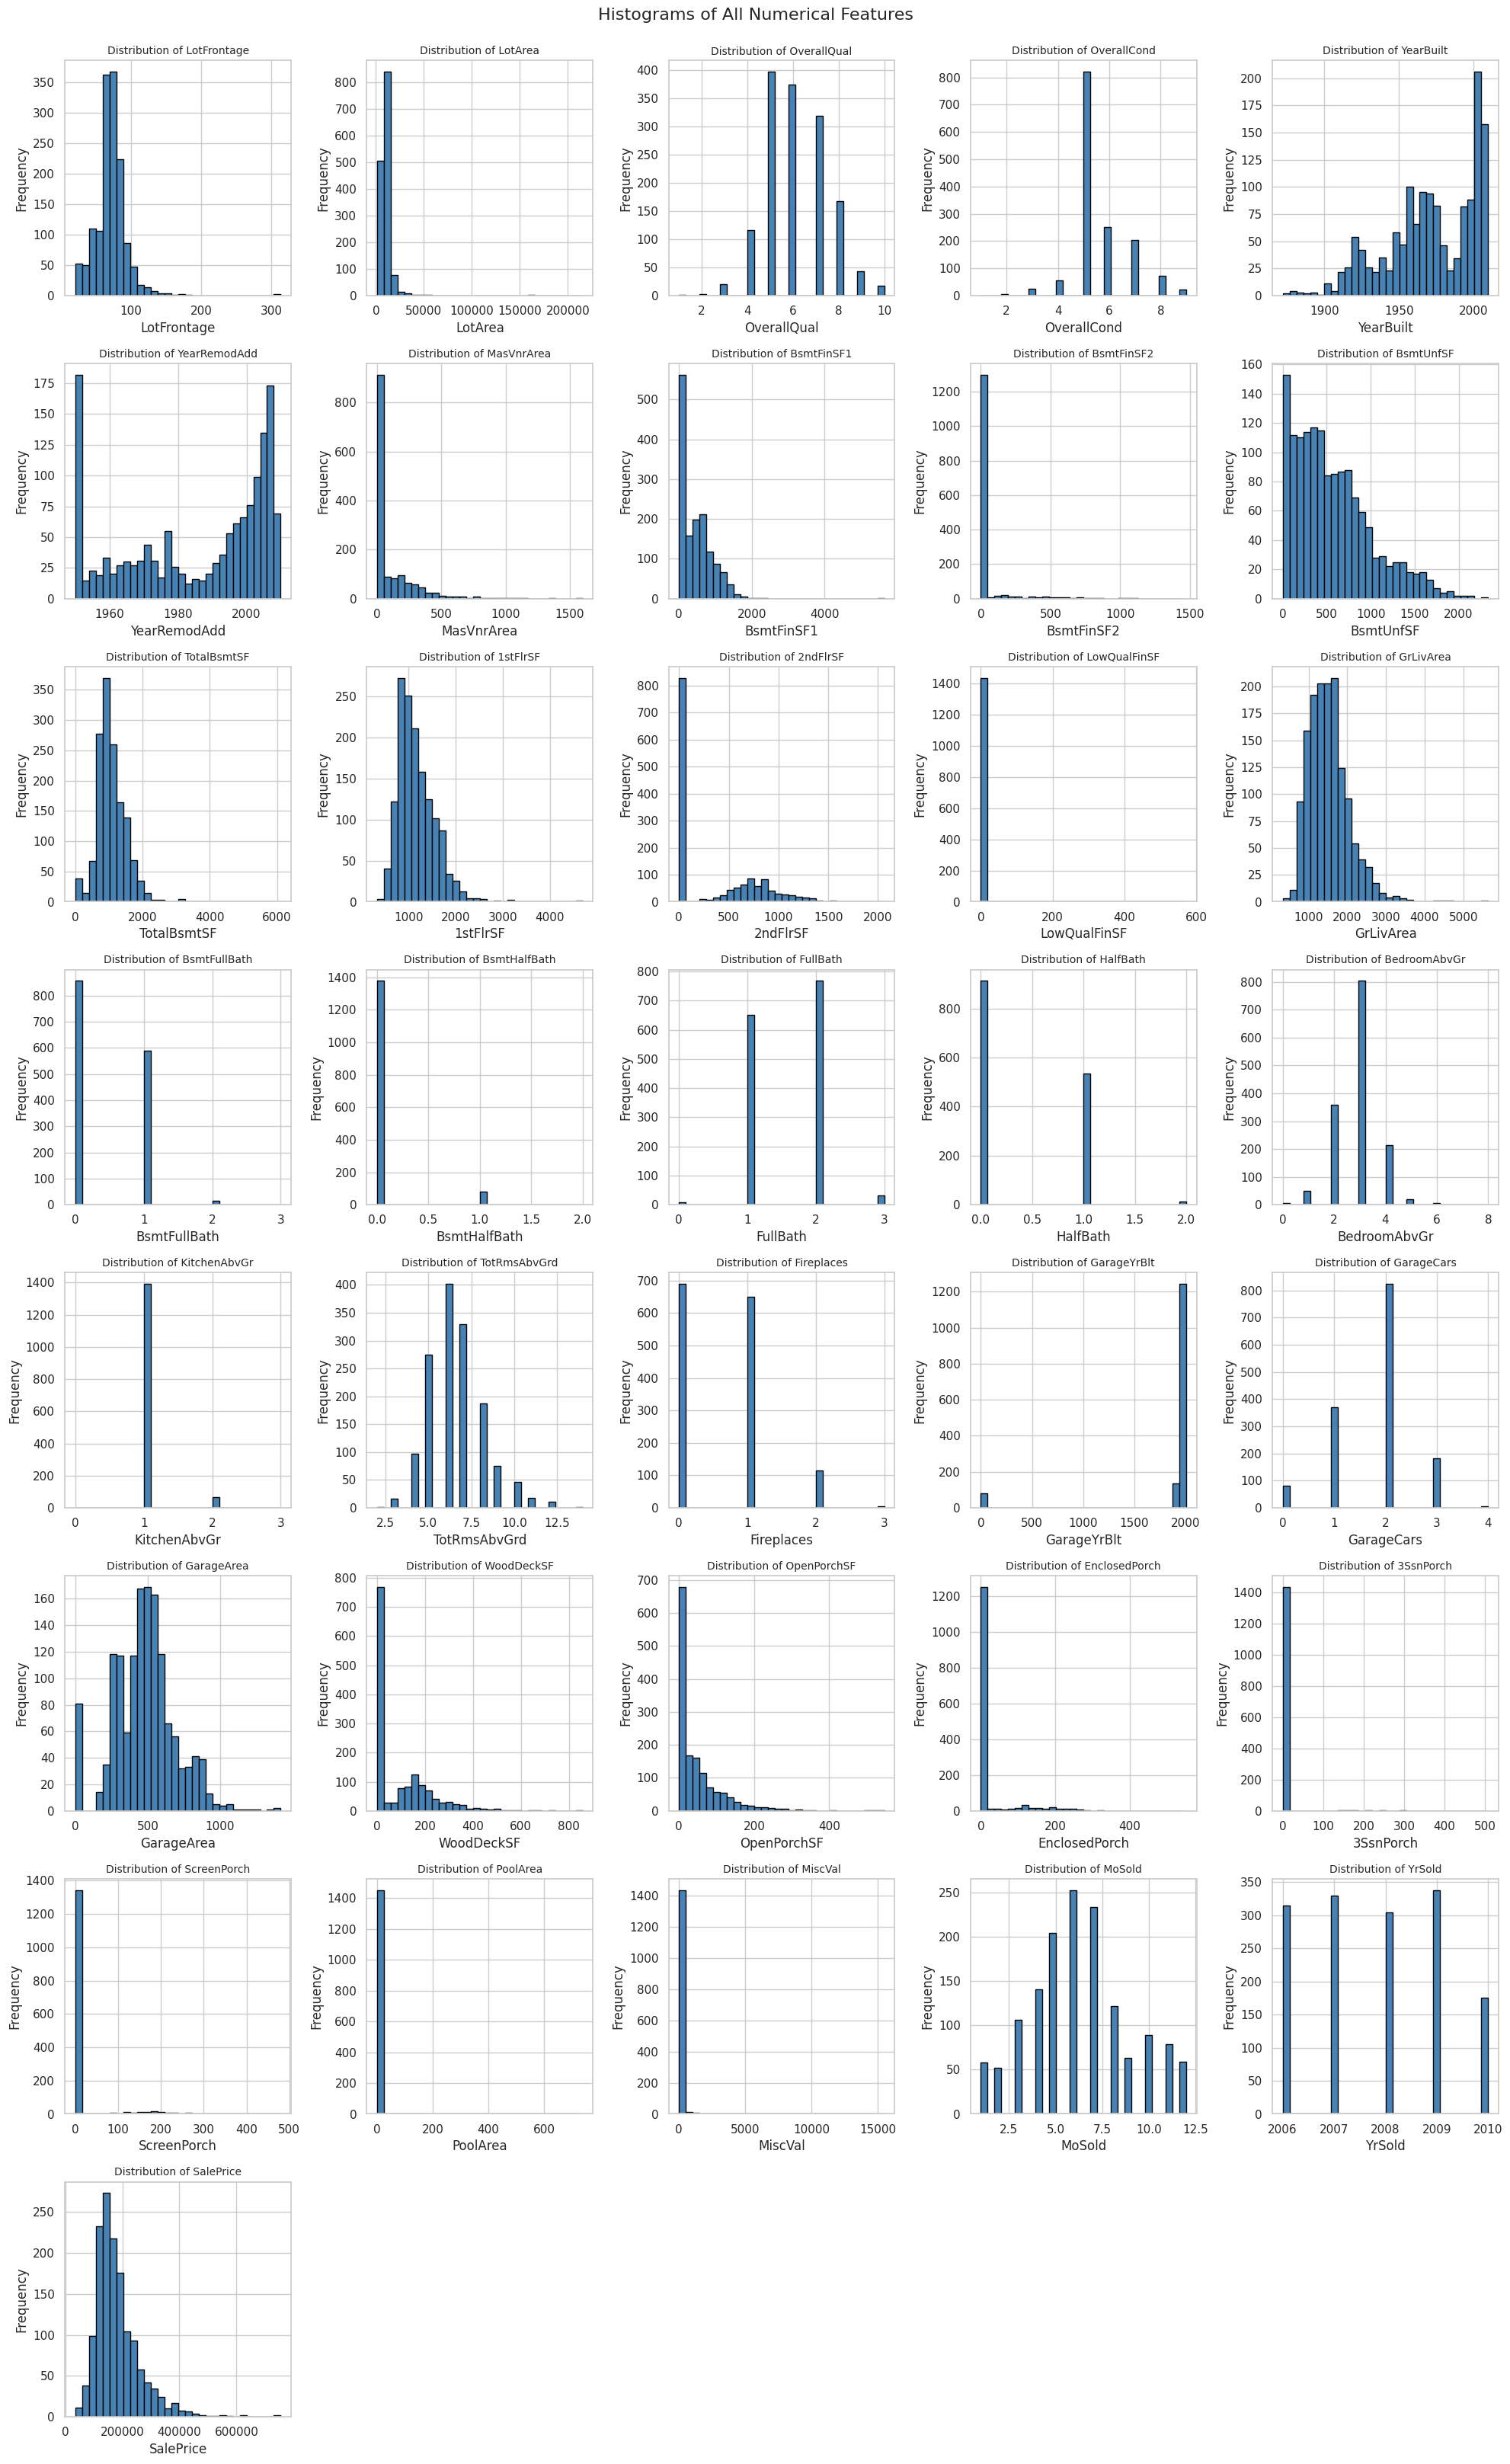

In [11]:
# Histograms for all numerical features
n_cols = 5
n_rows = int(np.ceil(len(numerical_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(f'Distribution of {col}', fontsize=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide any unused subplots
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Histograms of All Numerical Features', fontsize=16, y=1.01)
plt.show()

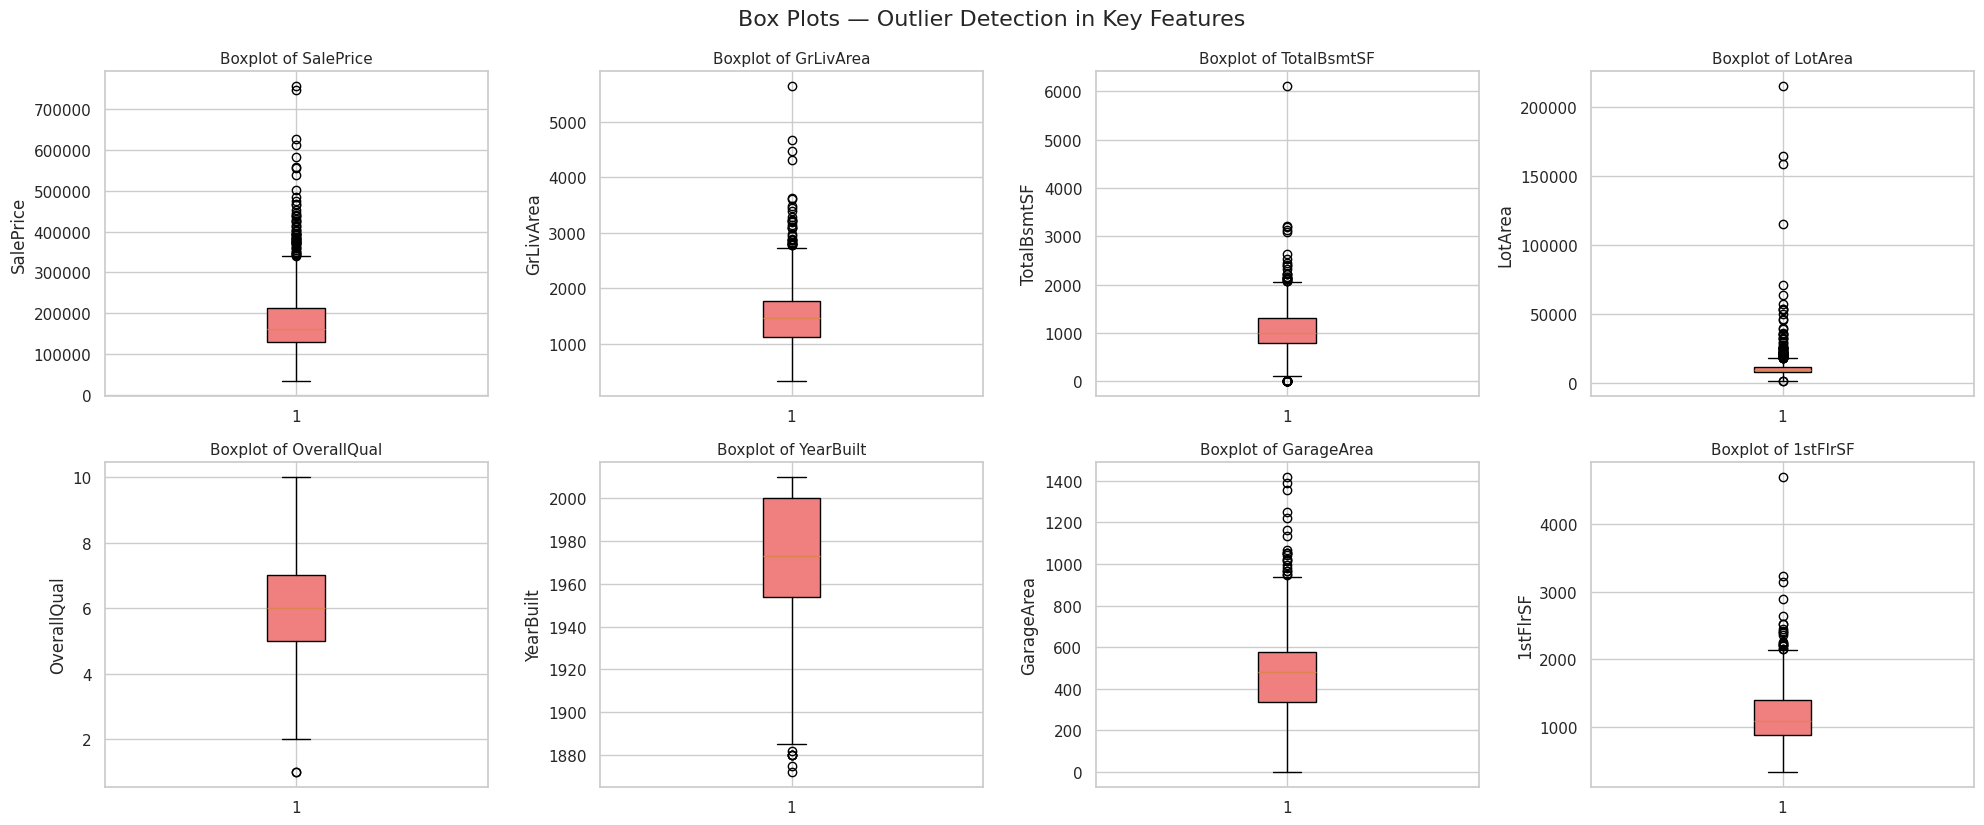

In [12]:
# Box plots for key features (identify outliers)
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(key_features):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                     boxprops=dict(facecolor='lightcoral'))
    axes[i].set_title(f'Boxplot of {col}', fontsize=11)
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.suptitle('Box Plots — Outlier Detection in Key Features', fontsize=16, y=1.03)
plt.show()

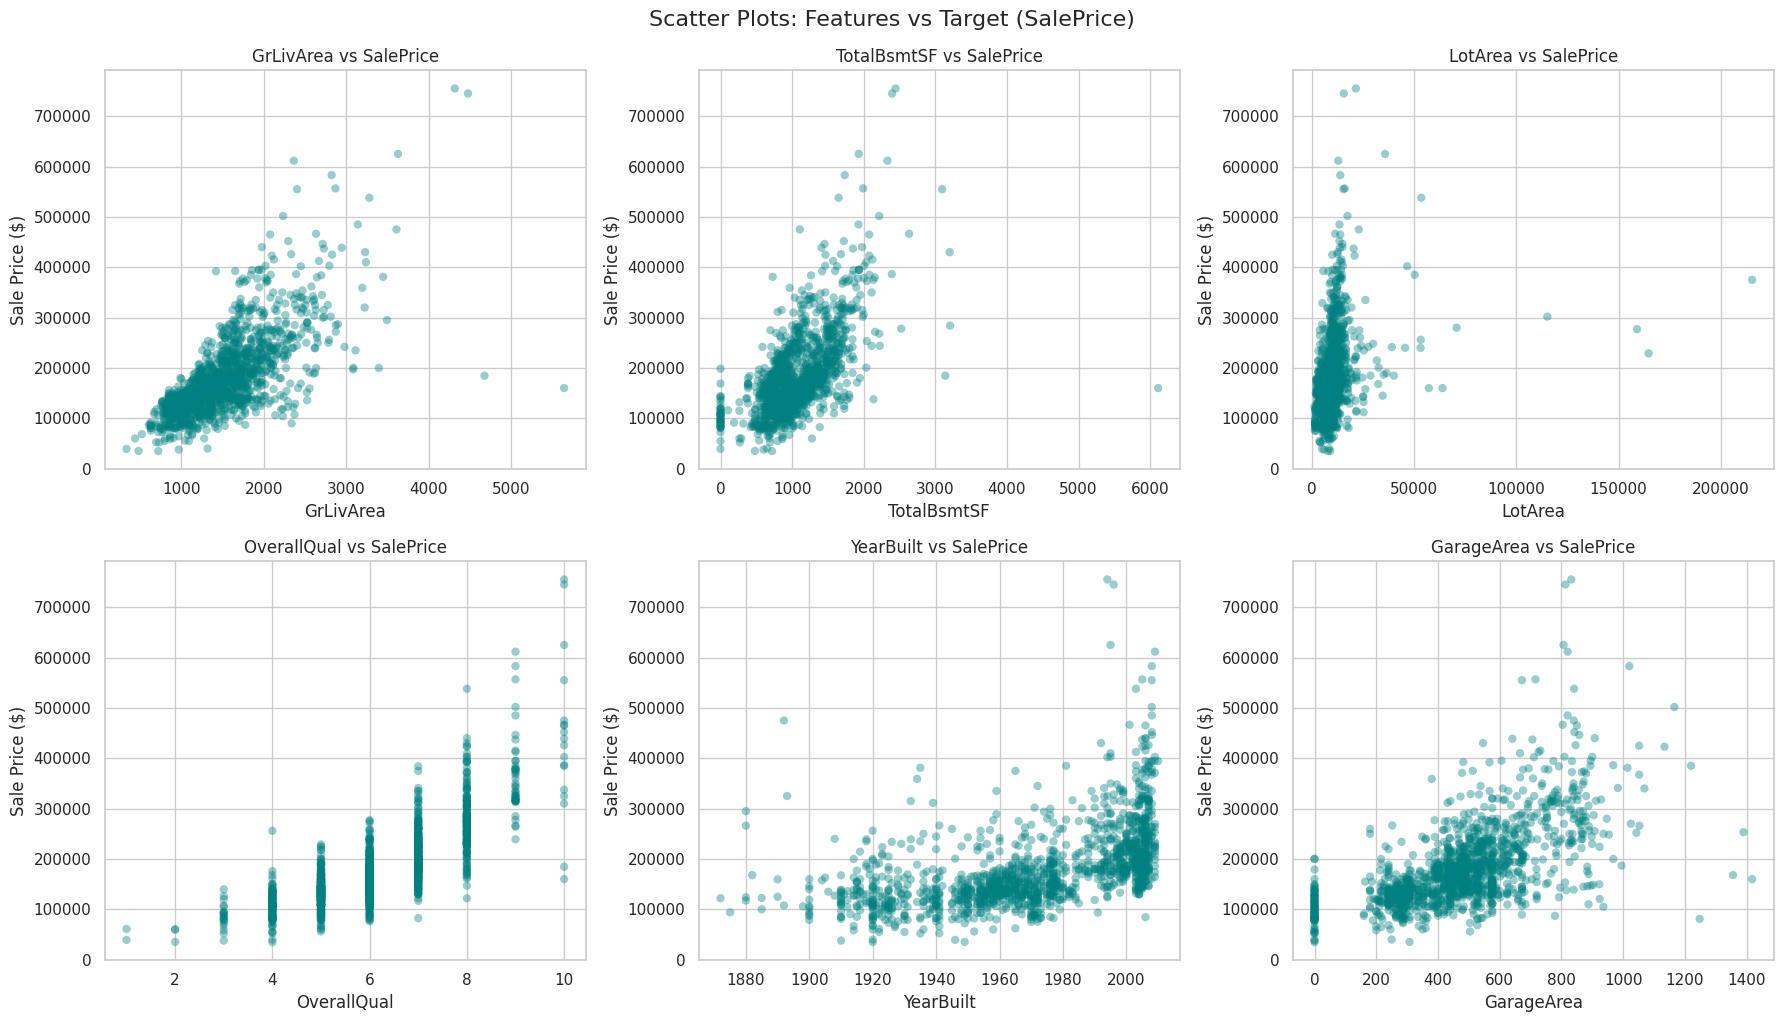

In [13]:
# Scatter plots: feature vs SalePrice (target variable)
scatter_features = ['GrLivArea', 'TotalBsmtSF', 'LotArea',
                     'OverallQual', 'YearBuilt', 'GarageArea']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(scatter_features):
    axes[i].scatter(df[col], df['SalePrice'], alpha=0.4, color='teal', edgecolor='none')
    axes[i].set_title(f'{col} vs SalePrice', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Sale Price ($)')

plt.tight_layout()
plt.suptitle('Scatter Plots: Features vs Target (SalePrice)', fontsize=16, y=1.02)
plt.show()

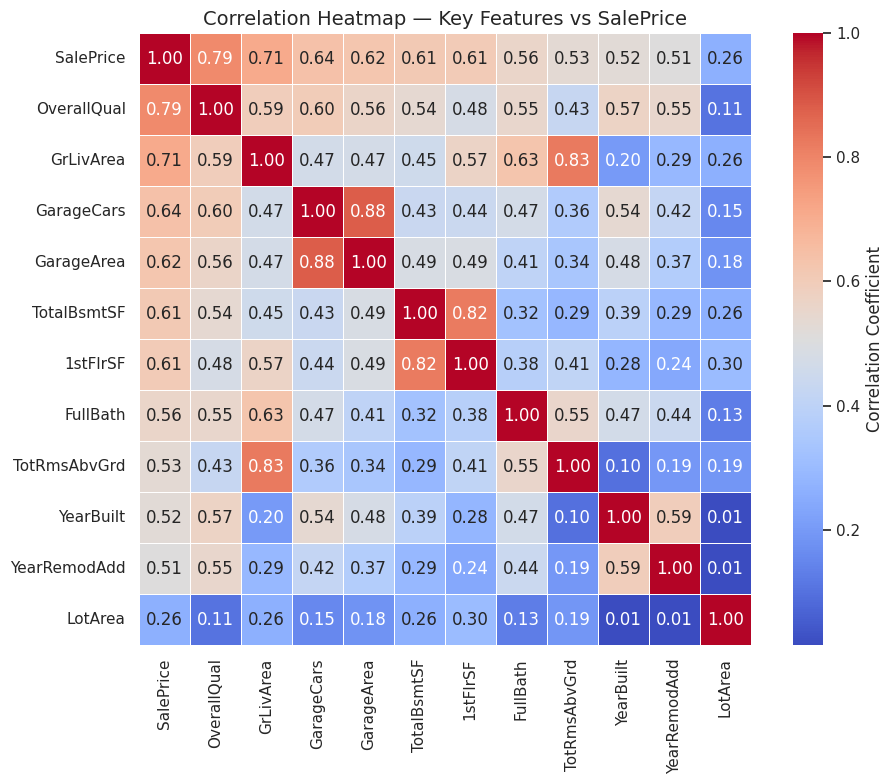

Top 5 features most correlated with SalePrice:
OverallQual    0.790982
GrLivArea      0.708624
GarageCars     0.640409
GarageArea     0.623431
TotalBsmtSF    0.613581
Name: SalePrice, dtype: float64


In [14]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr_features = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars',
                  'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath',
                  'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd', 'LotArea']
corr_matrix = df[corr_features].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Heatmap — Key Features vs SalePrice', fontsize=14)
plt.tight_layout()
plt.show()

print("Top 5 features most correlated with SalePrice:")
print(corr_matrix['SalePrice'].sort_values(ascending=False)[1:6])

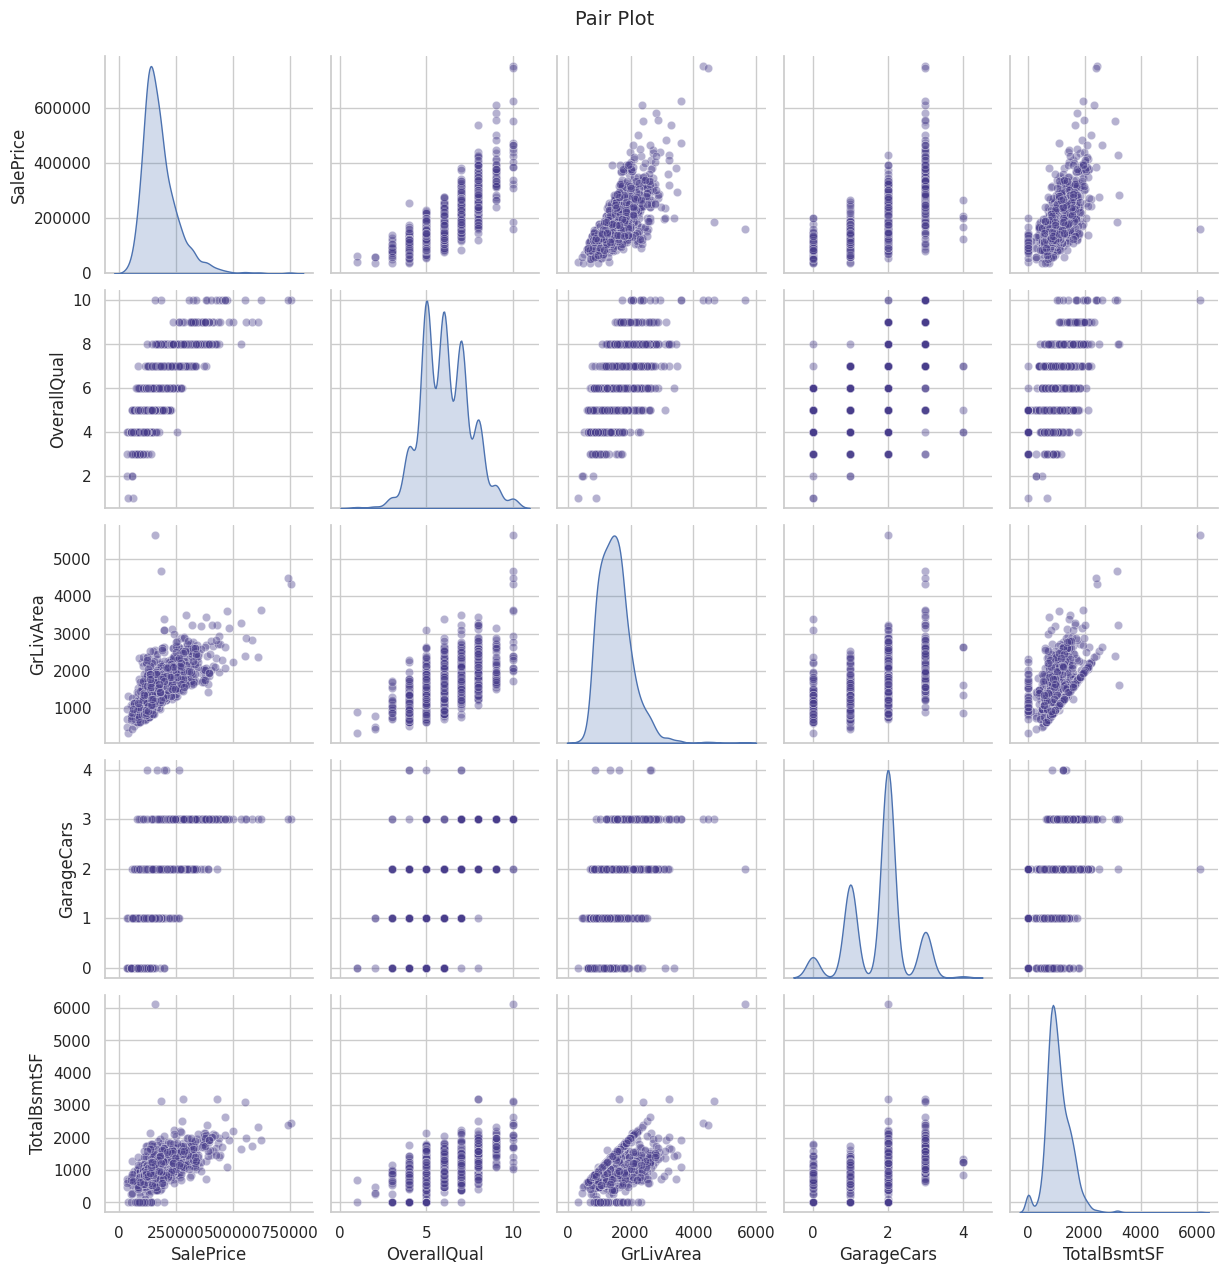

In [15]:
# Pair plot for the most important features
pairplot_features = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF']

sns.pairplot(df[pairplot_features], diag_kind='kde',
             plot_kws={'alpha': 0.4, 'color': 'darkslateblue'})
plt.suptitle('Pair Plot', y=1.02, fontsize=14)
plt.show()

## EDA Insights Summary

- **`OverallQual`, `GrLivArea`, `GarageCars`, `GarageArea`, and `TotalBsmtSF`**
  show the strongest positive correlation with `SalePrice`, making them strong
  predictor candidates.
- **Box plots** reveal clear outliers in `LotArea`, `GrLivArea`, and `SalePrice`
  — a handful of very large or very expensive homes sit far above the rest.
  These may need to be addressed before modeling (e.g., capping or removal).
- **Scatter plots** confirm mostly linear/positive relationships between living
  area, quality, and basement size with sale price, though variance increases
  at higher price points (heteroscedasticity).
- **Histograms** show several features are right-skewed (`SalePrice`,
  `GrLivArea`, `LotArea`), reinforcing the earlier skewness findings and
  suggesting log transformation ahead of modeling.

## Insights & Observations

1. **`OverallQual` has the strongest correlation with SalePrice (r = 0.79)**,
   making it the single best predictor in the dataset — even stronger than
   living area. This makes intuitive sense: buyers pay a premium for build
   and finish quality, not just size.

2. **`GrLivArea` (above-ground living area) is the second-strongest predictor
   (r = 0.71)**, followed by `GarageCars` (r = 0.64) and `GarageArea`
   (r = 0.62). Size-related features dominate the top of the correlation
   ranking, confirming that "bigger house = higher price" holds broadly.

3. **`KitchenAbvGr` (r = -0.14) and `EnclosedPorch` (r = -0.13) show weak
   negative correlation with price**, while `MoSold` (r = 0.05) and `YrSold`
   (r = -0.03) show almost no correlation at all — when a house was sold
   barely affects its price, which suggests the market was fairly stable
   across the 2006–2010 sale window in this dataset.

4. **`SalePrice` is strongly right-skewed (skewness = 1.88)**, with a mean of
   $180,921 pulled well above the median of $163,000. A small number of
   high-value homes drag the average up — this is a strong candidate for
   log-transformation before regression modeling.

5. **`GrLivArea` has 4 clear outliers above 4,000 sq ft**, and two of them
   (`GrLivArea` = 4,676 and 5,642 sq ft) sold for surprisingly low prices
   ($184,750 and $160,000) despite having the maximum `OverallQual` rating
   of 10. This is a data quality red flag — these two rows likely represent
   unusual sales (e.g., distressed or partial sales) and are candidates for
   removal before modeling.

6. **`LotArea` is extremely right-skewed (skewness = 12.2)**, with a median
   of 9,479 sq ft but a maximum of 215,245 sq ft — over 22x the median. This
   single extreme value will disproportionately influence any model that
   uses `LotArea` directly.

7. **Neighborhood location drives large price swings.** The most expensive
   neighborhood by average price, NoRidge (~$335,295), sells for over 3x
   the cheapest, MeadowV (~$98,576). This shows `Neighborhood` carries
   strong predictive signal despite being categorical, and should not be
   dropped in favor of only numeric features.

8. **`PoolArea` is almost entirely zero — only 7 of 1,460 houses (0.5%) have
   a pool.** This extreme sparsity means `PoolArea`/`PoolQC` will contribute
   little to a general model and may be better engineered into a simple
   "HasPool" binary flag instead of used as a raw numeric feature.

9. **`MiscVal` is the most skewed feature in the dataset (skewness = 24.5)**,
   with most values at 0 and a single extreme value of $15,500. Combined
   with its near-zero correlation to price (r = -0.02), this feature appears
   to add mostly noise rather than predictive value.

10. **`YearBuilt` correlates moderately with price (r = 0.52)**, confirming
    that newer homes tend to sell for more — but the relationship is weaker
    than size or quality features, suggesting renovations (`YearRemodAdd`)
    or condition may matter more than raw construction age alone.

11. **Most useful features for prediction**: based on correlation strength,
    `OverallQual`, `GrLivArea`, `GarageCars`, `GarageArea`, `TotalBsmtSF`,
    and `Neighborhood` stand out as the strongest candidates for a baseline
    regression model, while `PoolArea`, `MiscVal`, `MoSold`, and `YrSold`
    contribute little and could be dropped or heavily engineered.

In [16]:
# ================================
# Part 5: Simple Linear Regression
# ================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

## Feature Selection

Based on the correlation heatmap in Part 3 and the observations in Part 4,
`OverallQual` has the strongest correlation with `SalePrice` (**r = 0.79**),
higher than any other numeric feature, including `GrLivArea` (r = 0.71) and
`GarageCars` (r = 0.64). This makes it the best single-feature candidate for
a Simple Linear Regression model, since a stronger correlation means more of
the variance in price can be explained by this one variable.

In [17]:
# 1. Select feature and target
X = df[['OverallQual']]
y = df['SalePrice']

# 2. Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

# 3. Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Slope and intercept
slope = model.coef_[0]
intercept = model.intercept_
print(f"\nSlope (coefficient): {slope:.2f}")
print(f"Intercept: {intercept:.2f}")

Training set size: 1168 rows
Testing set size: 292 rows

Slope (coefficient): 44379.88
Intercept: -90233.22


## Interpreting the Slope

The regression equation is:

**SalePrice = 44,379.88 × OverallQual − 90,233.22**

This means: for every **1-point increase in Overall Quality rating** (on the
1–10 scale), the predicted sale price increases by approximately **$44,380**,
holding all else constant. The negative intercept (−$90,233) is a mathematical
artifact of the line's fit — it would represent the predicted price at
`OverallQual = 0`, which never actually occurs in the data (the scale starts
at 1), so it shouldn't be interpreted literally.

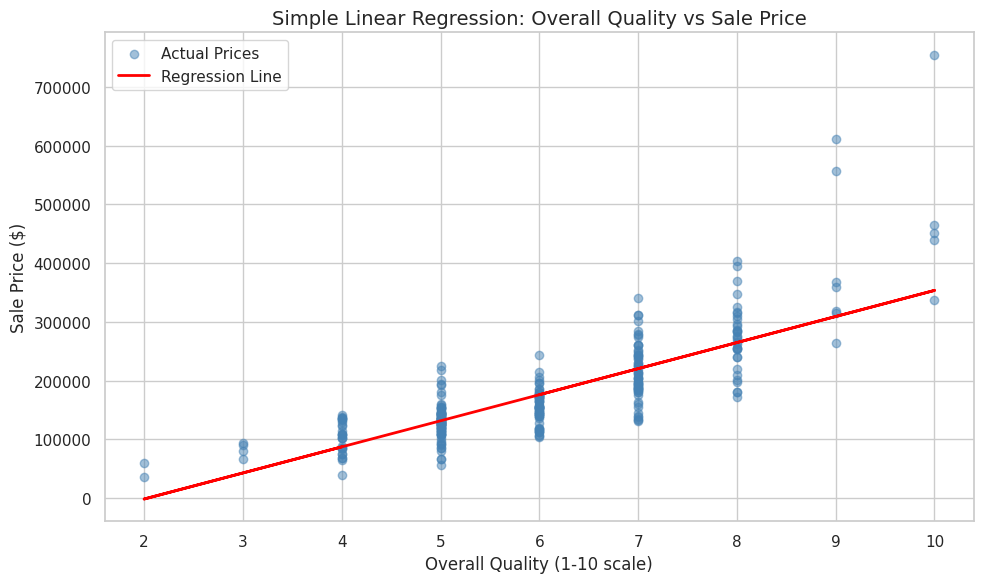

In [18]:
# 5. Make predictions on the test set
y_pred = model.predict(X_test)

# 6. Scatter plot with regression line
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, alpha=0.5, color='steelblue', label='Actual Prices')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Simple Linear Regression: Overall Quality vs Sale Price', fontsize=14)
plt.xlabel('Overall Quality (1-10 scale)')
plt.ylabel('Sale Price ($)')
plt.legend()
plt.tight_layout()
plt.show()

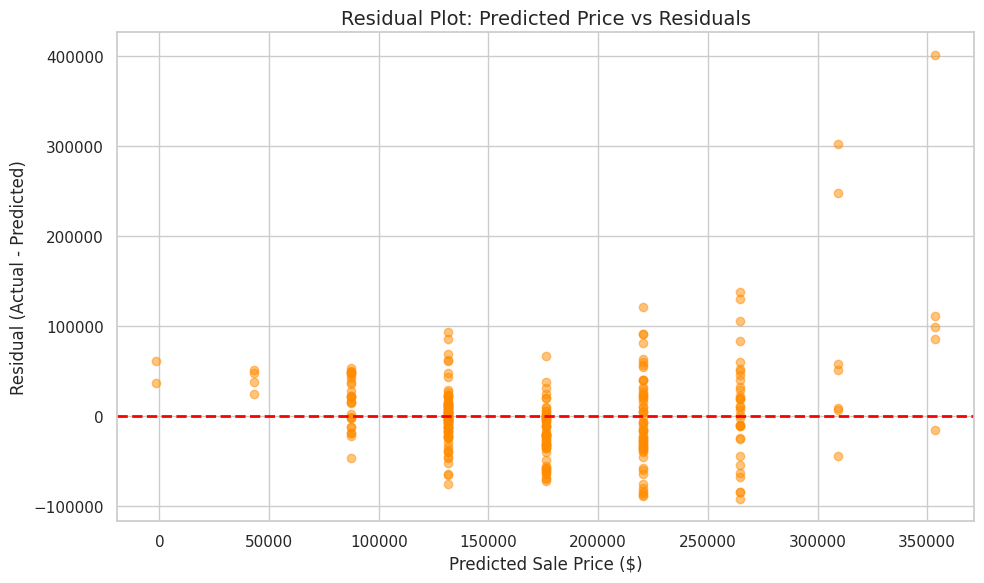

In [19]:
# 7. Residual plot
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5, color='darkorange')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Residual Plot: Predicted Price vs Residuals', fontsize=14)
plt.xlabel('Predicted Sale Price ($)')
plt.ylabel('Residual (Actual - Predicted)')
plt.tight_layout()
plt.show()

In [20]:
# 8. Evaluation metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score: {r2:.4f}")
print(f"MAE: ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")

R² Score: 0.6505
MAE: $33,343.24
RMSE: $51,778.63


## Model Interpretation — Is This a Good Model?

- **R² = 0.65** — `OverallQual` alone explains about 65% of the variance in
  `SalePrice`. This is a solid result for a single feature, confirming it's
  a strong predictor, but 35% of price variation is still unexplained.
- **MAE ≈ \$33,343** — on average, predictions are off by about \$33,000.
  Given the median sale price is ~\$163,000, that's roughly a 20% average
  error, which is fairly large for real-world use (e.g., pricing a house
  for sale).
- **RMSE ≈ \$51,779** — higher than MAE, indicating a few large errors
  (likely linked to the outlier high-value homes identified in Part 4) are
  pulling the error metric up.
- **Residual plot** shows the residual spread widening as predicted price
  increases (a funnel/fan shape) — this is heteroscedasticity, and it
  violates one of the core assumptions of linear regression (constant
  variance of errors). It suggests the relationship isn't perfectly linear,
  especially at the high end of the price range.

**Conclusion**: This is a *decent baseline* model — `OverallQual` is clearly
informative — but it is **not sufficient alone** for accurate price
prediction. The widening residuals and 35% unexplained variance suggest that
adding more features (multiple regression) would substantially improve
performance. This motivates the multiple regression model in the next part.

In [21]:
# ================================
# Part 6: Multiple Linear Regression
# ================================

## Feature Selection & Justification

I selected **5 features** based on Part 3's correlation analysis, combined
with domain knowledge to avoid redundant/collinear variables:

1. **`OverallQual`** (r = 0.79) — strongest single predictor; captures build
   and finish quality.
2. **`GrLivArea`** (r = 0.71) — second-strongest predictor; captures total
   living space, a fundamentally different dimension from quality.
3. **`GarageCars`** (r = 0.64) — captures garage capacity. I chose this over
   `GarageArea` (r = 0.62) because they are highly correlated with each other
   (both measure "garage size" in different units), and including both would
   introduce multicollinearity without adding new information.
4. **`TotalBsmtSF`** (r = 0.61) — captures basement size, a distinct spatial
   dimension not covered by `GrLivArea` (which only counts above-ground area).
5. **`YearBuilt`** (r = 0.52) — captures the age/modernity of the home, adding
   a time-based dimension the other four features don't cover.

Together these 5 features cover four distinct aspects of a house — **quality,
living space, basement space, garage capacity, and age** — rather than
picking 5 features that all measure roughly the same thing (e.g., avoiding
`1stFlrSF` and `TotRmsAbvGrd`, which overlap heavily with `GrLivArea`).

In [22]:
# 1. Select features and target
features = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'YearBuilt']
X = df[features]
y = df['SalePrice']

# 2. Split data (same random_state as Simple LR for fair comparison)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Train the model
mlr_model = LinearRegression()
mlr_model.fit(X_train, y_train)

# 4. Display and interpret coefficients
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': mlr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(f"Intercept: {mlr_model.intercept_:.2f}\n")
print("Coefficients:")
display(coef_df)

Intercept: -694533.36

Coefficients:


,Feature,Coefficient
0,OverallQual,20392.513001
2,GarageCars,15144.237204
4,YearBuilt,315.923350
1,GrLivArea,48.809801
3,TotalBsmtSF,25.365319


## Interpreting the Top 3 Coefficients

| Feature | Coefficient | Effect on Predicted Price |
|---|---|---|
| **OverallQual** | +\$20,392.51 | per 1-point increase in quality (1–10 scale) |
| **GarageCars** | +\$15,144.24 | per additional car of garage capacity |
| **YearBuilt** | +\$315.92 | per additional year of construction (newer home) |



- Each **1-point increase in `OverallQual`** adds about **\$20,393** to the predicted price.
- Each **additional garage space** (`GarageCars`) adds about **\$15,144**.
- Each **additional year** a home was built more recently (`YearBuilt`) adds about **\$316**.

---

**Why `OverallQual`'s coefficient shrank vs. Simple LR:**
In the Simple LR model, `OverallQual` alone had a coefficient of ~\$44,380 —
because it was absorbing the price effects of correlated features (size,
garage capacity, etc.) that weren't in the model. In Multiple LR, its
coefficient drops to ~\$20,393 because it now reflects only the *unique*
contribution of quality, after the other 4 features account for their own share.

In [23]:
# 5. Predictions and evaluation
y_pred_mlr = mlr_model.predict(X_test)

r2_mlr = r2_score(y_test, y_pred_mlr)
mae_mlr = mean_absolute_error(y_test, y_pred_mlr)
rmse_mlr = np.sqrt(mean_squared_error(y_test, y_pred_mlr))

print(f"R² Score: {r2_mlr:.4f}")
print(f"MAE: ${mae_mlr:,.2f}")
print(f"RMSE: ${rmse_mlr:,.2f}")

R² Score: 0.7939
MAE: $25,414.73
RMSE: $39,763.30


In [24]:
# 6. Comparison table: Simple LR vs Multiple LR
comparison = pd.DataFrame({
    'Metric': ['R² Score', 'MAE ($)', 'RMSE ($)'],
    'Simple LR (OverallQual)': [0.6505, 33343.24, 51778.63],
    'Multiple LR (5 features)': [round(r2_mlr, 4), round(mae_mlr, 2), round(rmse_mlr, 2)],
})
comparison['% Improvement'] = [
    f"+{(r2_mlr - 0.6505)/0.6505*100:.1f}%",
    f"-{(33343.24 - mae_mlr)/33343.24*100:.1f}%",
    f"-{(51778.63 - rmse_mlr)/51778.63*100:.1f}%",
]
display(comparison)

,Metric,Simple LR (OverallQual),Multiple LR (5 features),% Improvement
0,R² Score,0.6505,0.7939,+22.0%
1,MAE ($),33343.2400,25414.7300,-23.8%
2,RMSE ($),51778.6300,39763.3000,-23.2%


In [25]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    df[features], df['SalePrice'], test_size=0.2, random_state=42
)
mlr_model = LinearRegression()
mlr_model.fit(X_train_m, y_train_m)
y_pred_mlr = mlr_model.predict(X_test_m)

r2_mlr = r2_score(y_test_m, y_pred_mlr)
mae_mlr = mean_absolute_error(y_test_m, y_pred_mlr)
rmse_mlr = np.sqrt(mean_squared_error(y_test_m, y_pred_mlr))

print(f"R² Score: {r2_mlr:.4f}")
print(f"MAE: ${mae_mlr:,.2f}")
print(f"RMSE: ${rmse_mlr:,.2f}")

R² Score: 0.7939
MAE: $25,414.73
RMSE: $39,763.30


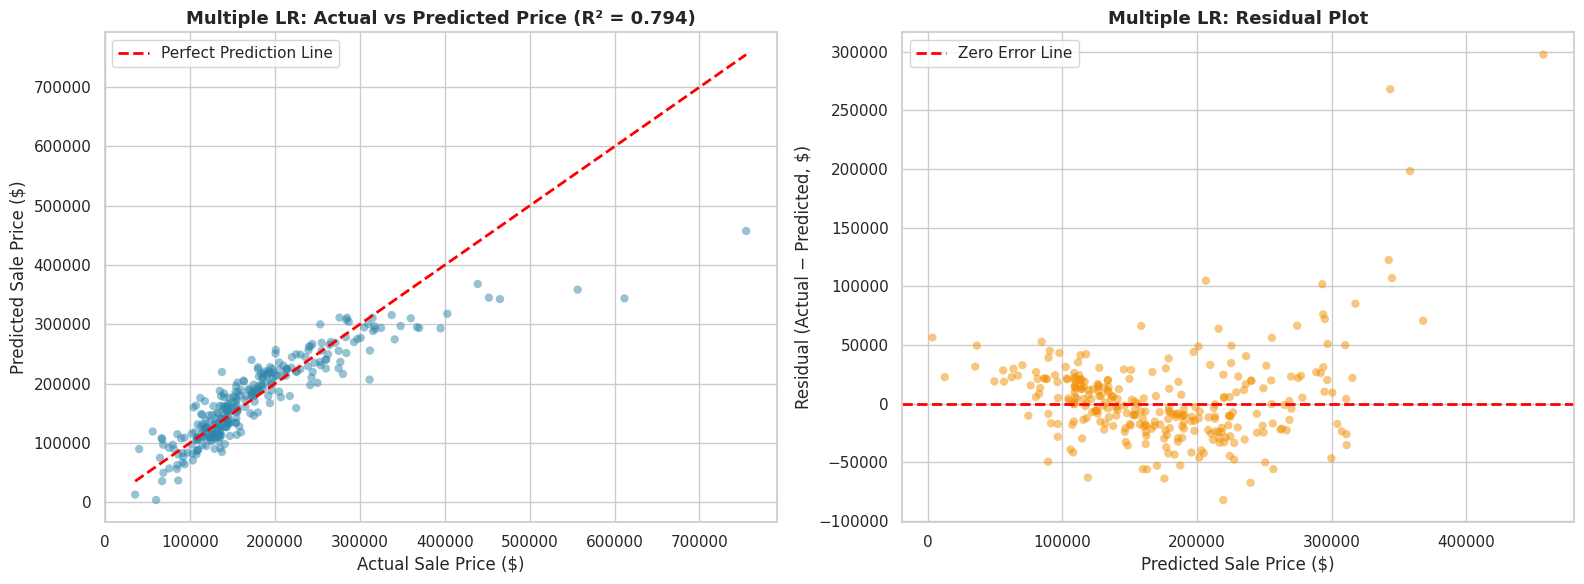

In [26]:
# ================================
# Multiple LR — Visualizations (Actual vs Predicted, Residuals)
# ================================

y_pred_mlr = mlr_model.predict(X_test_m)
residuals_mlr = y_test_m - y_pred_mlr

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Actual vs Predicted
axes[0].scatter(y_test_m, y_pred_mlr, alpha=0.5, color='#2E86AB', edgecolor='none')
axes[0].plot([y_test_m.min(), y_test_m.max()], [y_test_m.min(), y_test_m.max()],
             color='red', linestyle='--', linewidth=2, label='Perfect Prediction Line')
axes[0].set_title(f'Multiple LR: Actual vs Predicted Price (R² = {r2_mlr:.3f})',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Actual Sale Price ($)')
axes[0].set_ylabel('Predicted Sale Price ($)')
axes[0].legend()

# 2. Residual plot
axes[1].scatter(y_pred_mlr, residuals_mlr, alpha=0.5, color='#F18F01', edgecolor='none')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error Line')
axes[1].set_title('Multiple LR: Residual Plot', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Sale Price ($)')
axes[1].set_ylabel('Residual (Actual − Predicted, $)')
axes[1].legend()

plt.tight_layout()
plt.show()

## Model Comparison

| Metric | Simple LR | Multiple LR | Improvement |
|---|---|---|---|
| R² Score | 0.6505 | 0.7939 | +22.0% |
| MAE (\$) | 33,343.24 | 25,414.73 | -23.8% (lower is better) |
| RMSE (\$) | 51,778.63 | 39,763.30 | -23.2% (lower is better) |

## Discussion

**Did adding more features improve the model? By how much?**
Yes, substantially. R² increased from 0.65 to 0.79 — a **22% relative
improvement**, meaning the model now explains about 79% of the variance in
`SalePrice` instead of 65%. Both error metrics dropped by roughly 23–24%:
average prediction error (MAE) fell from ~\$33,343 to ~\$25,415, a difference
of nearly \$8,000 per house.

**Which features contributed most to the prediction?**
Based on coefficient magnitude, `OverallQual` remains the single strongest
contributor (~\$20,393 per quality point), followed by `GarageCars`
(~\$15,144 per car). `TotalBsmtSF` and `GrLivArea` have smaller per-unit
effects, but high leverage since square footage varies over a wide range —
for example, a 500 sq ft increase in `GrLivArea` adds ~\$24,405 at
\$48.81/sq ft.

**Since performance did improve, why?**
This is expected because the 5 selected features capture **different,
largely non-redundant dimensions** of a house (quality, above-ground space,
basement space, garage capacity, age). Simple LR could only use one
dimension (`OverallQual`) and had to absorb the effects of the other
correlated variables into a single coefficient, which is less precise.
Multiple LR isolates each feature's unique contribution, which is why the
error dropped and R² rose. The remaining ~21% unexplained variance likely
comes from features not included here (e.g., `Neighborhood`, which Part 4
showed causes large price swings) and from the outlier high-value homes
identified in Part 4, which no linear model handles well.

In [27]:
# ================================
# Part 7: Visualization Portfolio
# ================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Consistent style for the whole portfolio
sns.set_style("whitegrid")
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

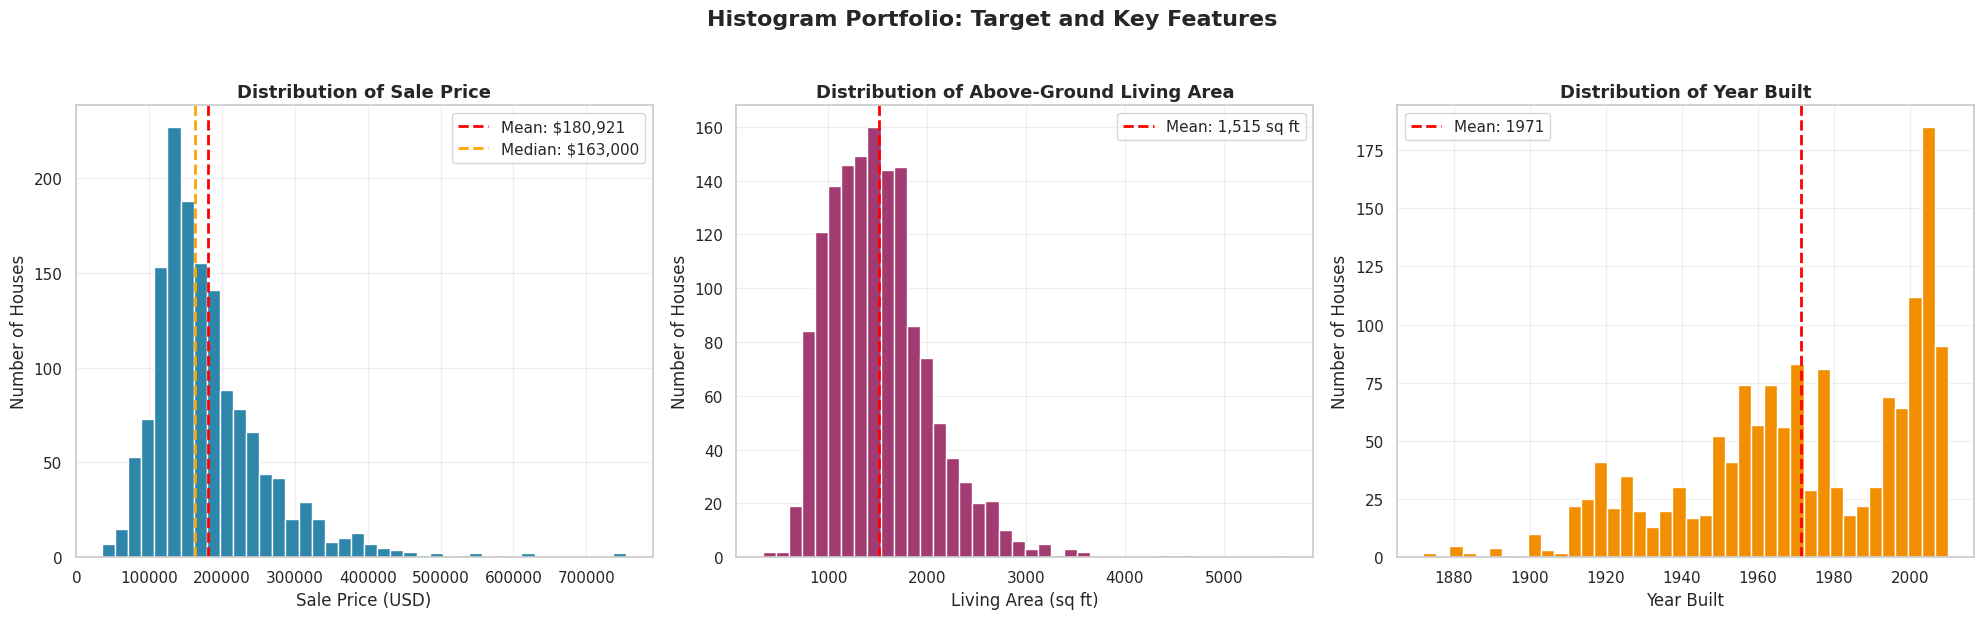

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# SalePrice (target)
axes[0].hist(df['SalePrice'], bins=40, color='#2E86AB', edgecolor='white')
axes[0].axvline(df['SalePrice'].mean(), color='red', linestyle='--',
                 linewidth=2, label=f"Mean: ${df['SalePrice'].mean():,.0f}")
axes[0].axvline(df['SalePrice'].median(), color='orange', linestyle='--',
                 linewidth=2, label=f"Median: ${df['SalePrice'].median():,.0f}")
axes[0].set_title('Distribution of Sale Price', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sale Price (USD)')
axes[0].set_ylabel('Number of Houses')
axes[0].legend()

# GrLivArea
axes[1].hist(df['GrLivArea'], bins=40, color='#A23B72', edgecolor='white')
axes[1].axvline(df['GrLivArea'].mean(), color='red', linestyle='--',
                 linewidth=2, label=f"Mean: {df['GrLivArea'].mean():,.0f} sq ft")
axes[1].set_title('Distribution of Above-Ground Living Area', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Living Area (sq ft)')
axes[1].set_ylabel('Number of Houses')
axes[1].legend()

# YearBuilt
axes[2].hist(df['YearBuilt'], bins=40, color='#F18F01', edgecolor='white')
axes[2].axvline(df['YearBuilt'].mean(), color='red', linestyle='--',
                 linewidth=2, label=f"Mean: {df['YearBuilt'].mean():.0f}")
axes[2].set_title('Distribution of Year Built', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Year Built')
axes[2].set_ylabel('Number of Houses')
axes[2].legend()

plt.suptitle('Histogram Portfolio: Target and Key Features', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

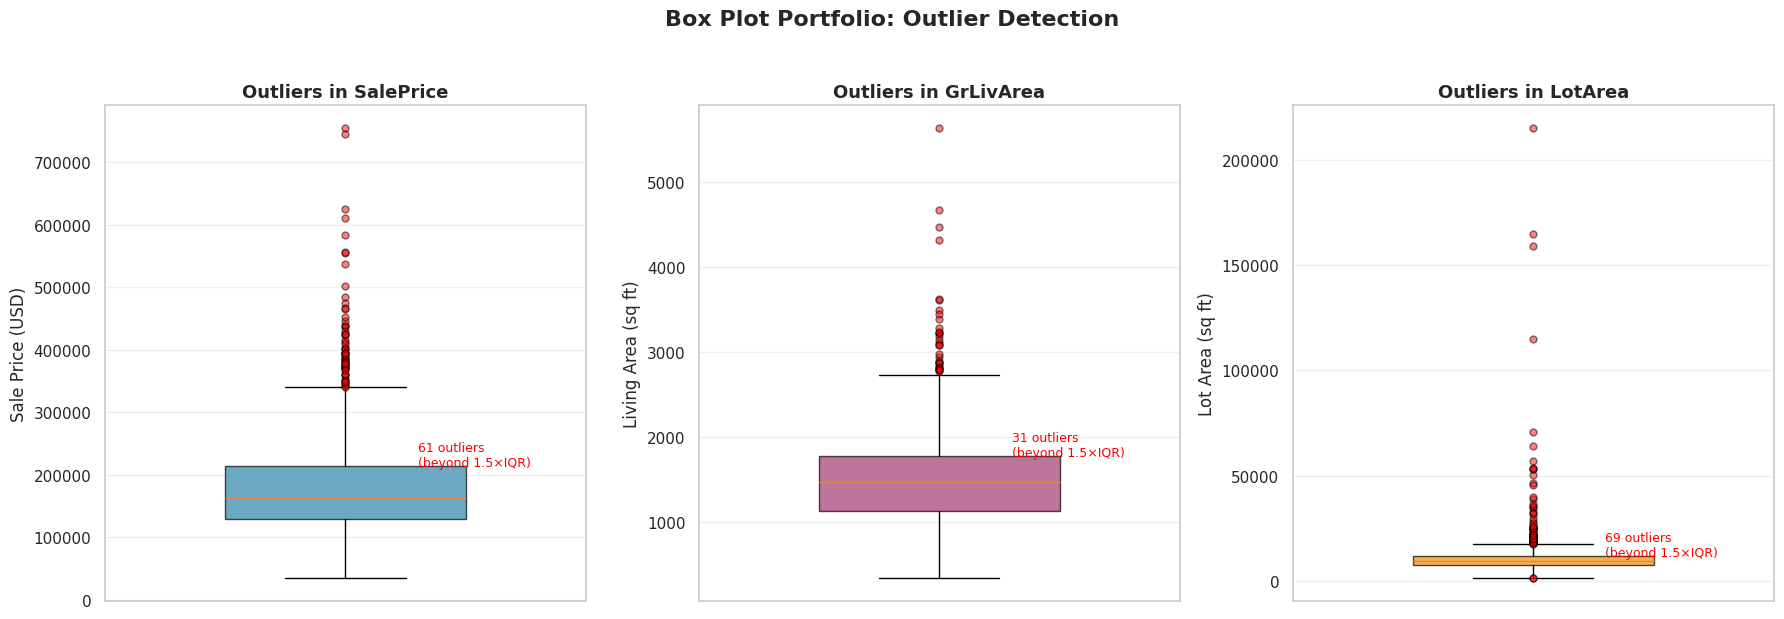

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

box_features = [('SalePrice', 'Sale Price (USD)', '#2E86AB'),
                 ('GrLivArea', 'Living Area (sq ft)', '#A23B72'),
                 ('LotArea', 'Lot Area (sq ft)', '#F18F01')]

for ax, (col, label, color) in zip(axes, box_features):
    bp = ax.boxplot(df[col], patch_artist=True, widths=0.5,
                     flierprops=dict(marker='o', markerfacecolor='red',
                                      markersize=5, alpha=0.5))
    bp['boxes'][0].set_facecolor(color)
    bp['boxes'][0].set_alpha(0.7)
    ax.set_title(f'Outliers in {col}', fontsize=13, fontweight='bold')
    ax.set_ylabel(label)
    ax.set_xticks([])

    # Annotate outlier count
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_outliers = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    ax.annotate(f'{n_outliers} outliers\n(beyond 1.5×IQR)',
                xy=(1.15, df[col].quantile(0.75)), fontsize=9,
                color='red', ha='left')

plt.suptitle('Box Plot Portfolio: Outlier Detection', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

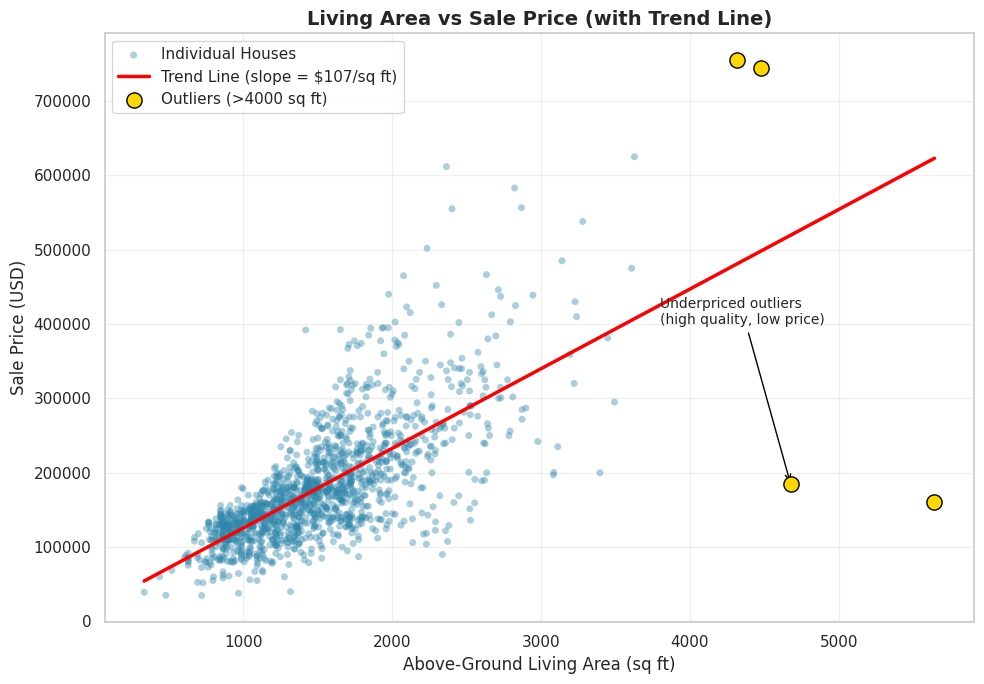

In [30]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(df['GrLivArea'], df['SalePrice'], alpha=0.4, color='#2E86AB',
           edgecolor='none', s=25, label='Individual Houses')

# Trend line (simple linear fit for visualization)
z = np.polyfit(df['GrLivArea'], df['SalePrice'], 1)
trend_x = np.linspace(df['GrLivArea'].min(), df['GrLivArea'].max(), 100)
trend_y = np.polyval(z, trend_x)
ax.plot(trend_x, trend_y, color='red', linewidth=2.5,
        label=f'Trend Line (slope = ${z[0]:.0f}/sq ft)')

# Highlight the outliers identified in Part 4
outliers = df[df['GrLivArea'] > 4000]
ax.scatter(outliers['GrLivArea'], outliers['SalePrice'], color='gold',
           edgecolor='black', s=120, zorder=5, label='Outliers (>4000 sq ft)')
ax.annotate('Underpriced outliers\n(high quality, low price)',
            xy=(4676, 184750), xytext=(3800, 400000),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=10)

ax.set_title('Living Area vs Sale Price (with Trend Line)', fontsize=14, fontweight='bold')
ax.set_xlabel('Above-Ground Living Area (sq ft)')
ax.set_ylabel('Sale Price (USD)')
ax.legend()
plt.tight_layout()
plt.show()

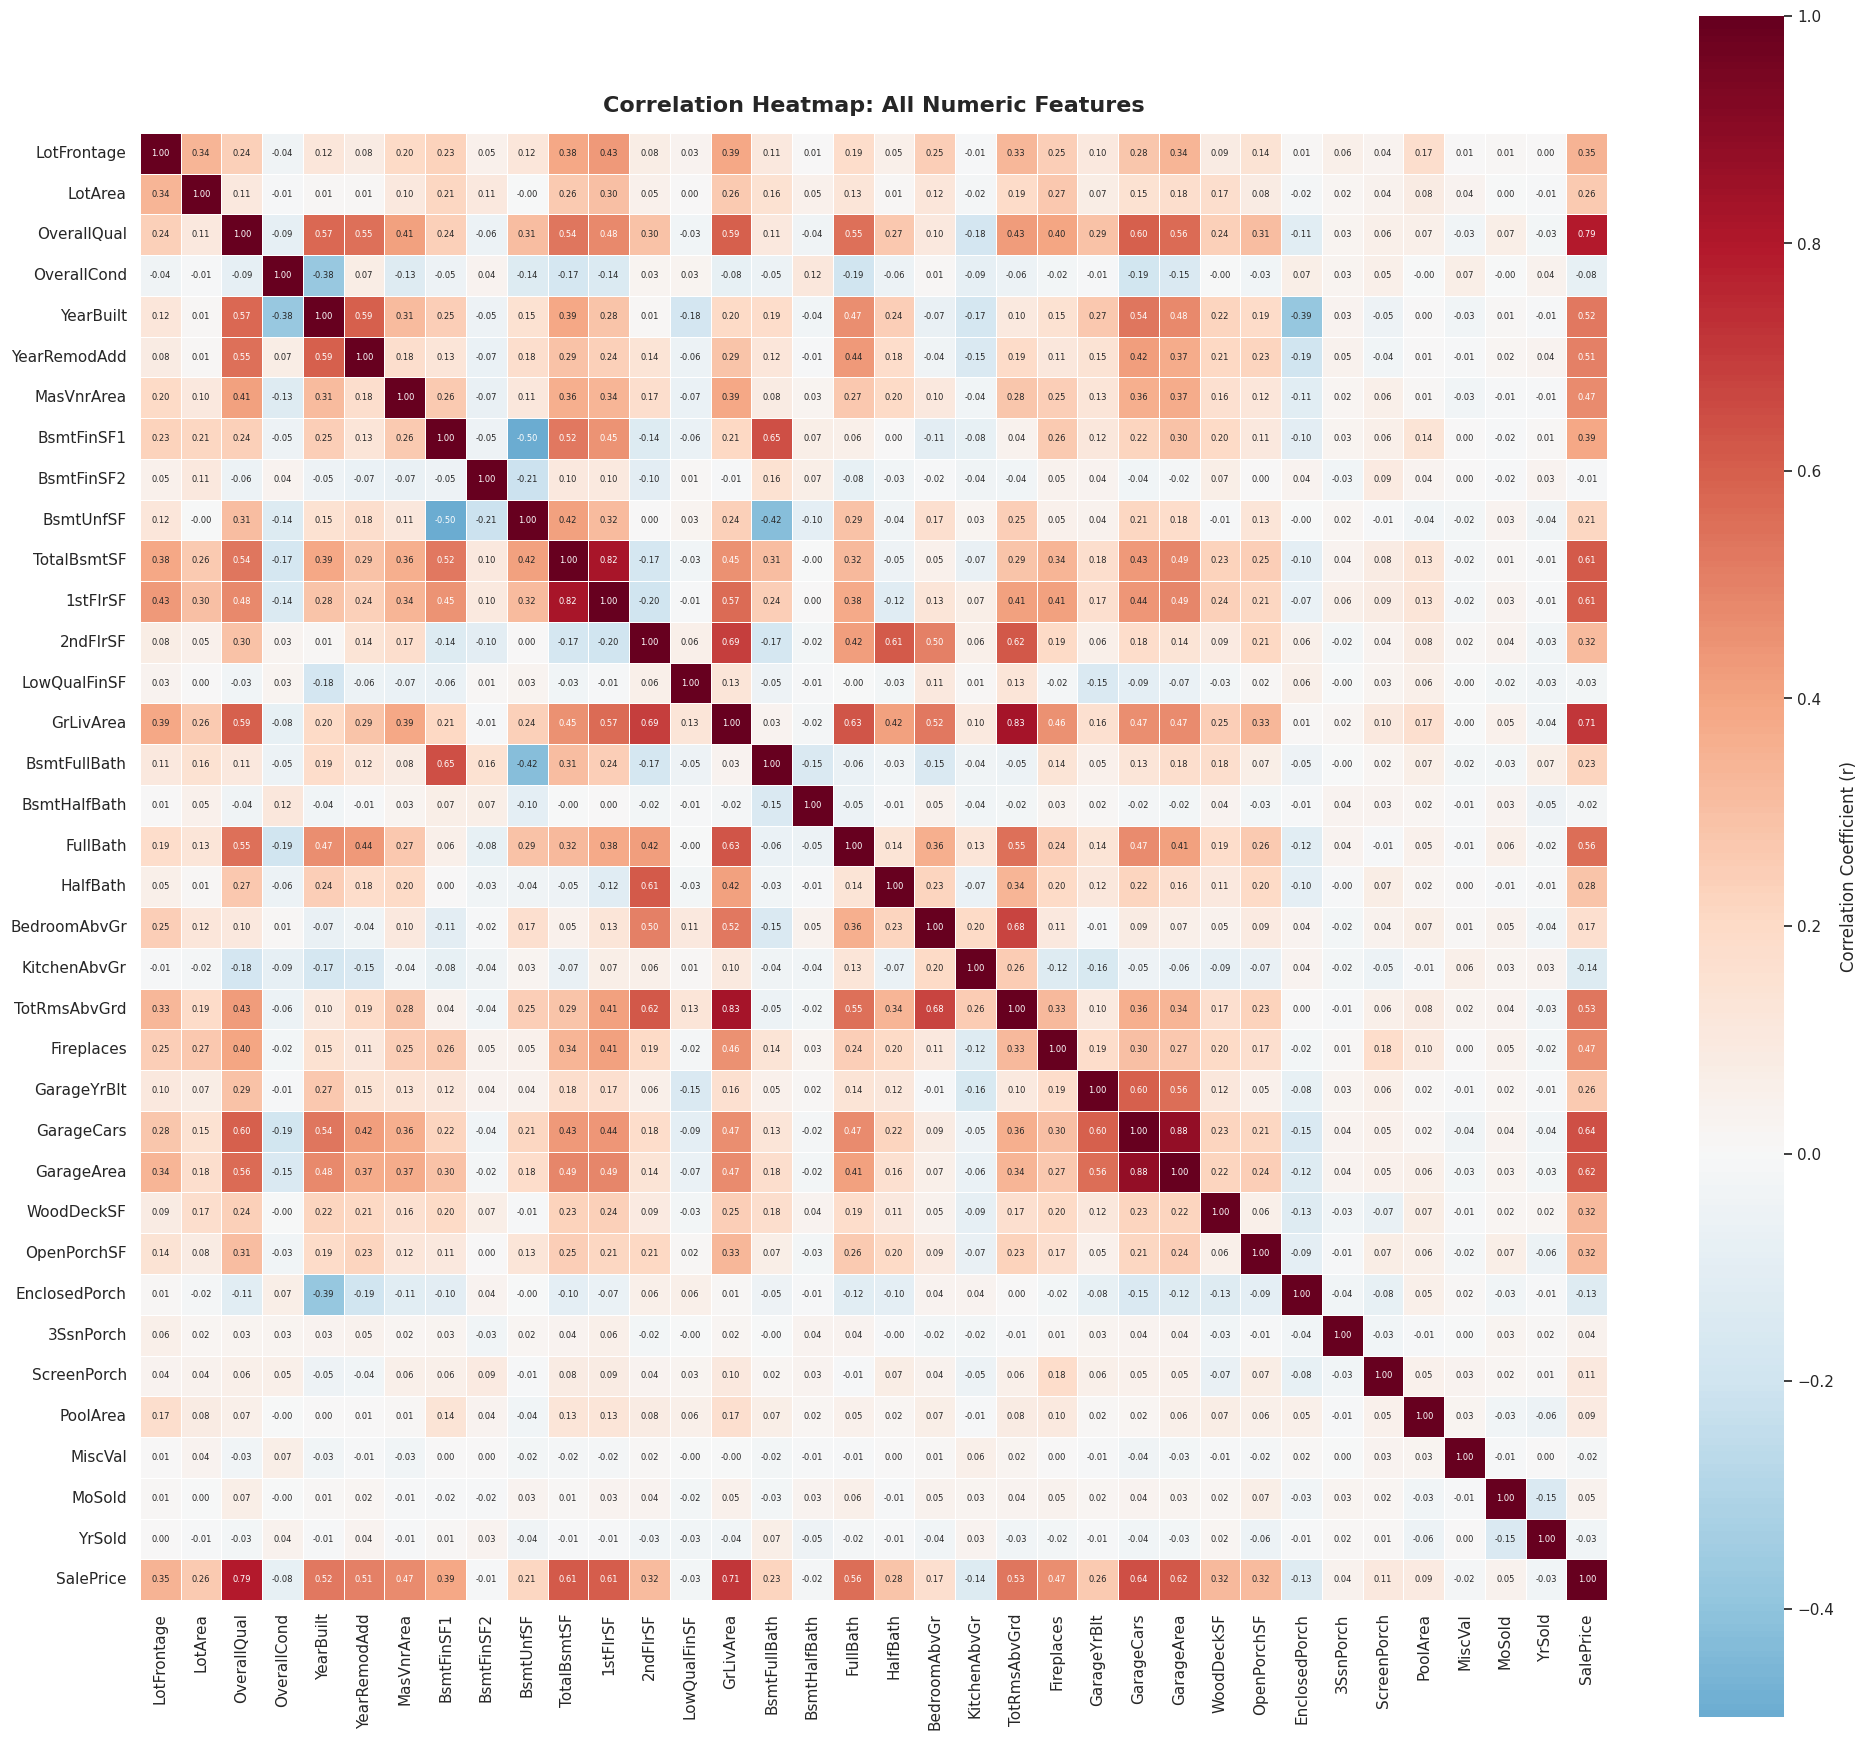

In [31]:

fig, ax = plt.subplots(figsize=(20, 18))

full_numeric = df.select_dtypes(include=['int64', 'float64']).drop(columns=['Id'])
full_corr = full_numeric.corr()

sns.heatmap(full_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'label': 'Correlation Coefficient (r)'},
            annot_kws={'size': 6}, ax=ax)
ax.set_title('Correlation Heatmap: All Numeric Features', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [32]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    df[['OverallQual']], df['SalePrice'], test_size=0.2, random_state=42
)
model = LinearRegression()
model.fit(X_train_s, y_train_s)
y_pred_simple = model.predict(X_test_s)

In [33]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    df[features], df['SalePrice'], test_size=0.2, random_state=42
)
mlr_model = LinearRegression()
mlr_model.fit(X_train_m, y_train_m)
y_pred_mlr = mlr_model.predict(X_test_m)

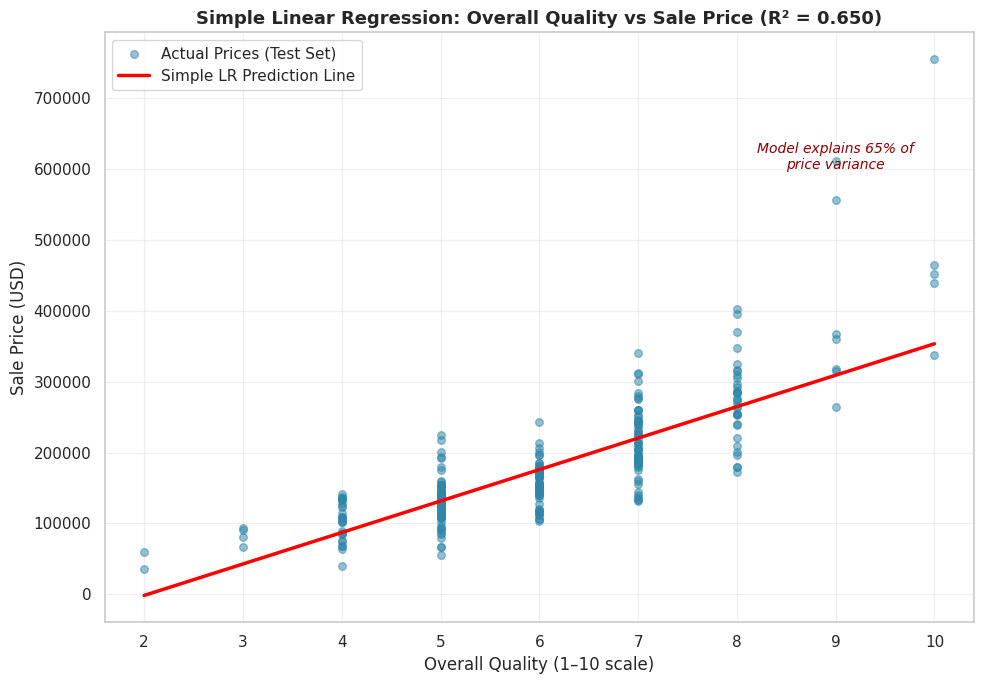

In [34]:

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(X_test_s, y_test_s, alpha=0.5, color='#2E86AB', s=30, label='Actual Prices (Test Set)')
sorted_X = X_test_s.sort_values('OverallQual')
ax.plot(sorted_X, model.predict(sorted_X), color='red', linewidth=2.5,
        label='Simple LR Prediction Line')

r2_val = r2_score(y_test_s, model.predict(X_test_s))
ax.set_title(f'Simple Linear Regression: Overall Quality vs Sale Price (R² = {r2_val:.3f})',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Overall Quality (1–10 scale)')
ax.set_ylabel('Sale Price (USD)')
ax.legend()
ax.annotate(f'Model explains {r2_val*100:.0f}% of\nprice variance',
            xy=(9, 600000), fontsize=10, color='darkred', style='italic',
            ha='center')
plt.tight_layout()
plt.show()

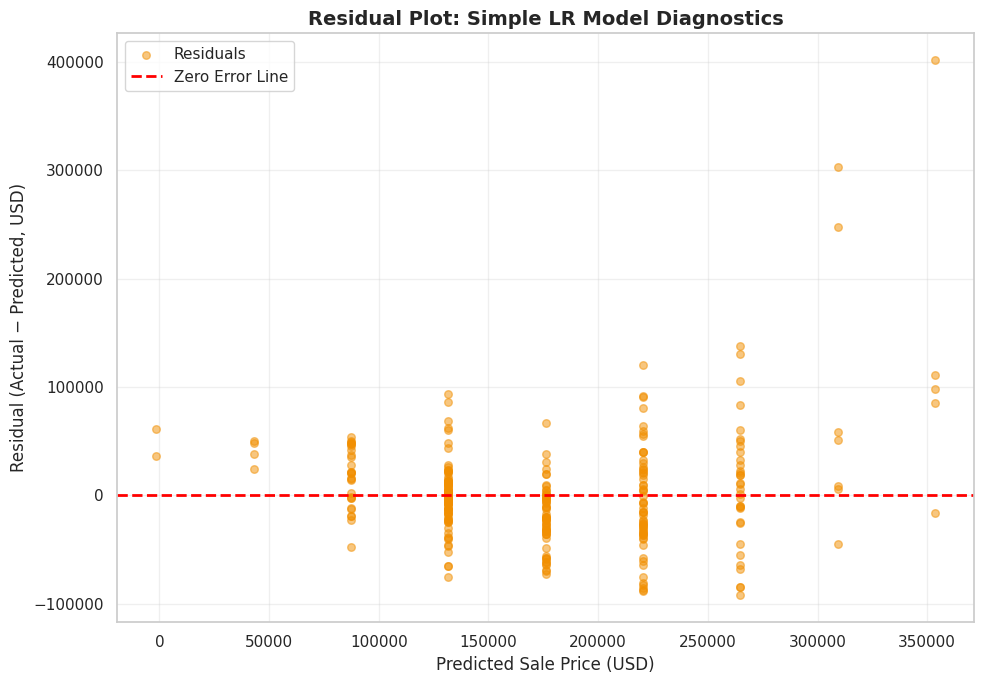

In [35]:

fig, ax = plt.subplots(figsize=(10, 7))

y_pred_simple = model.predict(X_test_s)
residuals_simple = y_test_s - y_pred_simple

ax.scatter(y_pred_simple, residuals_simple, alpha=0.5, color='#F18F01', s=30,
           label='Residuals')
ax.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error Line')

ax.set_title('Residual Plot: Simple LR Model Diagnostics', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Sale Price (USD)')
ax.set_ylabel('Residual (Actual − Predicted, USD)')
ax.legend()
ax.annotate('Funnel shape indicates\nheteroscedasticity',
            xy=(400000, 100000), fontsize=10, color='darkred',
            ha='center', style='italic')
plt.tight_layout()
plt.show()

## Visualization Portfolio Summary

This portfolio covers all 6 required chart types:
1. **Histograms** — distributions of `SalePrice`, `GrLivArea`, and `YearBuilt`,
   with mean/median lines marking skew.
2. **Box plots** — outlier detection for `SalePrice`, `GrLivArea`, `LotArea`,
   with outlier counts annotated.
3. **Scatter plot with trend line** — `GrLivArea` vs `SalePrice`, with the
   4 known outlier houses highlighted and annotated.
4. **Correlation heatmap** — full color-coded matrix of 12 key numeric features.
5. **Regression line plot** — Simple LR prediction line over actual test data,
   with R² in the title.
6. **Residual plot** — diagnostic check showing the heteroscedasticity
   (funnel shape) noted in Part 5.

Each chart uses a consistent, non-default color palette, has descriptive
titles, labeled axes with units, gridlines, and legends where multiple series
are shown.

## Part 8 — Conclusion & Reflection


**What I learned.** Cleaning the data took way more effort than fitting the
model. Deciding what to do with missing values in columns like `PoolQC` or
`LotFrontage` wasn't just running `.fillna()` — I had to actually look at
why each column was missing before deciding how to fix it. I also saw
directly why correlation analysis matters: it's the reason `OverallQual`
ended up being a better predictor than square footage, which I expected to
be the strongest feature.

**Most surprising finding.** Two houses with a perfect 10/10 quality rating
and over 4,300 sq ft of space sold for only $160,000 – $185,000 way below
what similar houses went for. On paper they look like outliers, but they're
probably just unusual sales (foreclosure, family sale, etc.). It was a good
reminder that not every strange data point is an error.

**Challenges.** I hit a real bug in Part 7: I reused the name `X_test` for
both the Simple and Multiple Linear Regression models, so the second
`train_test_split` overwrote the first one, and the model broke with a
feature-mismatch error. Fixing it taught me to always use different variable
names for different models (`X_test_s` vs `X_test_m`) instead of recycling
the same ones.

**Real business use.** A model like this could help a real estate company
or a bank quickly flag listings that are priced way above or below what the
data suggests they should be. Since `OverallQual` and `GrLivArea` alone get
you to a 79% R², you don't need anything complicated to get a solid first
estimate.

**What I'd do differently.** I'd add `Neighborhood` as a feature next time —
Part 4 showed a 3x price gap between the cheapest and priciest neighborhoods,
which is a bigger effect than most of the numeric features I used. I'd also
try log-transforming `SalePrice` to fix the skew and the funnel-shaped
residuals, and eventually test a Random Forest model against this one to see
if it handles the non-linear patterns better.

**Connection to ML.** This assignment made R², MAE, and RMSE feel real
instead of just formulas. I could see exactly how adding features changed
each one. It also showed me how a simple model can misattribute credit: when
I only used `OverallQual`, its coefficient was almost double what it became
once other features were added, because it was picking up the effect of
things like garage size and basement area on its own.

**Open questions.** I'd like to understand how to properly handle
multicollinearity between features like `GarageCars` and `GarageArea` instead
of just picking one and dropping the other.

In [36]:
# ================================
# Stretch Goal: Random Forest vs Linear Regression
# ================================
from sklearn.ensemble import RandomForestRegressor

# Use the same features and split as Multiple LR
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train_m, y_train_m)
y_pred_rf = rf_model.predict(X_test_m)

r2_rf = r2_score(y_test_m, y_pred_rf)
mae_rf = mean_absolute_error(y_test_m, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_m, y_pred_rf))

print(f"Random Forest R²: {r2_rf:.4f}")
print(f"Random Forest MAE: ${mae_rf:,.2f}")
print(f"Random Forest RMSE: ${rmse_rf:,.2f}")

# 3-way comparison table
comparison_rf = pd.DataFrame({
    'Metric': ['R² Score', 'MAE ($)', 'RMSE ($)'],
    'Simple LR': [0.6505, 33343.24, 51778.63],
    'Multiple LR': [0.7939, 25414.73, 39763.30],
    'Random Forest': [round(r2_rf, 4), round(mae_rf, 2), round(rmse_rf, 2)],
})
display(comparison_rf)

Random Forest R²: 0.8874
Random Forest MAE: $19,202.18
Random Forest RMSE: $29,386.20


,Metric,Simple LR,Multiple LR,Random Forest
0,R² Score,0.6505,0.7939,0.8874
1,MAE ($),33343.2400,25414.7300,19202.1800
2,RMSE ($),51778.6300,39763.3000,29386.2000


## Random Forest vs Linear Regression

| Metric | Simple LR | Multiple LR | Random Forest |
|---|---|---|---|
| R² Score | 0.6505 | 0.7939 | 0.8874 |
| MAE (\$) | 33,343.24 | 25,414.73 | 19,202.18 |
| RMSE (\$) | 51,778.63 | 39,763.30 | 29,386.20 |

**Why Random Forest performs better here:** Random Forest builds many decision
trees and averages their predictions, which lets it capture **non-linear
relationships and interactions between features** that a linear model can't.
For example, the effect of `GrLivArea` on price might depend on `OverallQual`
(a large low-quality house may not be worth as much as a large high-quality
one) — linear regression assumes each feature's effect is constant and
additive, while Random Forest can naturally model that kind of interaction.
It's also more robust to the outliers and skew identified in Part 4, since
tree splits aren't affected by extreme values the way a linear fit's
coefficients are. The tradeoff: Random Forest is a "black box" — the
coefficients we interpreted in Part 6 don't exist here, so it's harder to
explain *why* it makes a specific prediction.

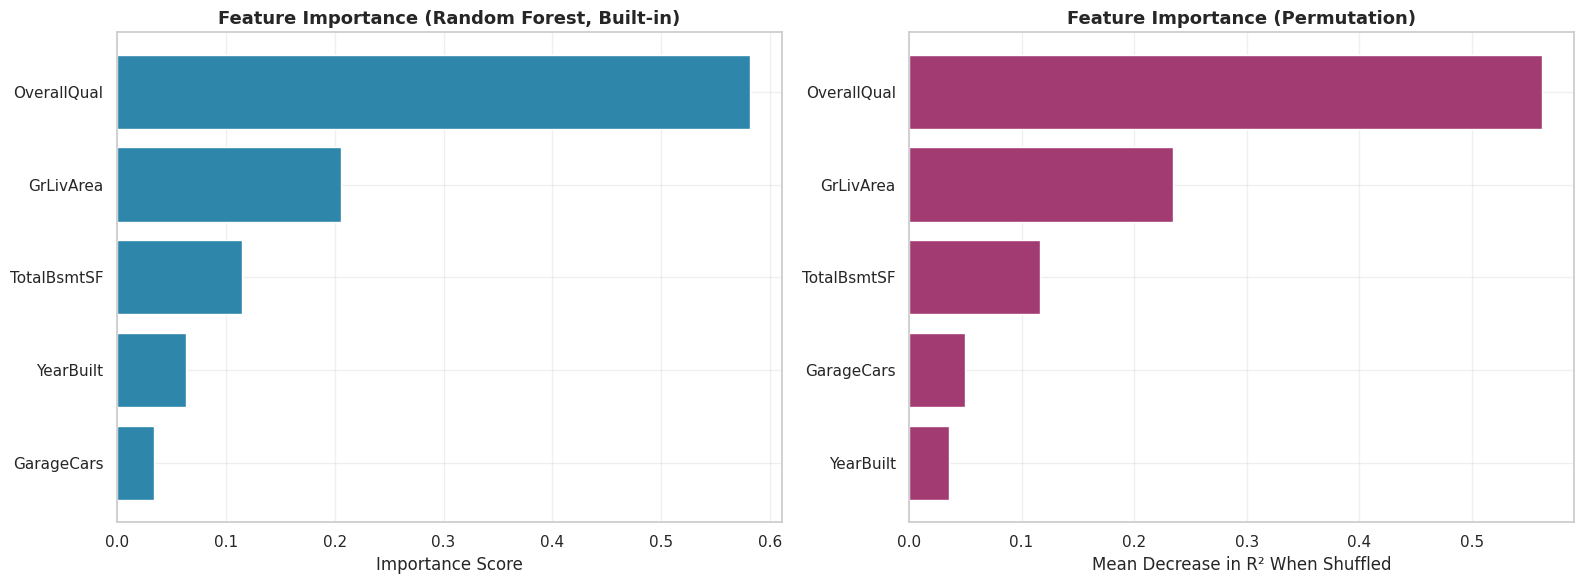

In [37]:
# ================================
# Stretch Goal: Feature Importance Analysis
# ================================
from sklearn.inspection import permutation_importance

# Method 1: Built-in Random Forest importance (Gini/impurity-based)
rf_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Method 2: Permutation importance (more reliable — measures actual performance drop)
perm_result = permutation_importance(rf_model, X_test_m, y_test_m, n_repeats=10, random_state=42)
perm_importance = pd.DataFrame({
    'Feature': features,
    'Importance': perm_result.importances_mean
}).sort_values('Importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(rf_importance['Feature'], rf_importance['Importance'], color='#2E86AB')
axes[0].set_title('Feature Importance (Random Forest, Built-in)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Importance Score')
axes[0].invert_yaxis()

axes[1].barh(perm_importance['Feature'], perm_importance['Importance'], color='#A23B72')
axes[1].set_title('Feature Importance (Permutation)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Mean Decrease in R² When Shuffled')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [38]:
# ================================
# Stretch Goal: Interactive Plotly Visualizations
# ================================
!pip install plotly --quiet
import plotly.express as px
import plotly.graph_objects as go

# 1. Interactive scatter plot (zoom, hover, filter by Neighborhood)
fig1 = px.scatter(df, x='GrLivArea', y='SalePrice', color='Neighborhood',
                   hover_data=['OverallQual', 'YearBuilt'],
                   title='Living Area vs Sale Price (Interactive, by Neighborhood)',
                   labels={'GrLivArea': 'Living Area (sq ft)', 'SalePrice': 'Sale Price ($)'})
fig1.update_layout(title_font_size=16)
fig1.show()

# 2. Interactive correlation heatmap
corr_features = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars',
                  'TotalBsmtSF', 'YearBuilt', 'LotArea']
corr_matrix_plotly = df[corr_features].corr()

fig2 = px.imshow(corr_matrix_plotly, text_auto='.2f', color_continuous_scale='RdBu_r',
                  title='Interactive Correlation Heatmap', aspect='auto')
fig2.update_layout(title_font_size=16)
fig2.show()

# 3. Interactive box plot (hover to see exact quartile values)
fig3 = px.box(df, y='SalePrice', x='OverallQual',
              title='Sale Price Distribution by Overall Quality (Interactive)',
              labels={'OverallQual': 'Overall Quality (1-10)', 'SalePrice': 'Sale Price ($)'},
              color='OverallQual')
fig3.update_layout(title_font_size=16, showlegend=False)
fig3.show()